# Dynamic Ride Pricing
# Georgia Zavou, Ilaria Curzi, Theodoros Lambrou


The Dataset we chose has Dynamic Data for Ride Priciing
In this dataset the currency used is not specified (it is counted in units)
We also don´t know the location that these rides took place.



# Aim
Our aim is to analyse this dataset and find which fetures affect dynamic pricing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ColabNotebooks/dynamic_pricing.csv"

df = pd.read_csv(file_path)


Print some information about our dataset

In [ ]:

df.info()

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


What type of columns we have

| **Column Name**            | **What It Represents**                                                                 |
|----------------------------|----------------------------------------------------------------------------------------|
| `Number_of_Riders`         | Total number of ride requests at that time (measures demand)                        |
| `Number_of_Drivers`        | Number of available drivers nearby (measures supply)                                |
| `Location_Category`        | Location type where the ride was requested: Urban, Suburban, or Rural               |
| `Vehicle_Type`             | Type of vehicle selected: Standard, Premium, or Luxury                              |
| `Customer_Loyalty_Status`  | Customer’s loyalty tier: Regular, Silver, or Premium                                |
| `Average_Ratings`          | Average rating of the customer from previous rides ( 1 to 5)               |
| `Number_of_Past_Rides`     | Number of rides the customer has taken before                                       |
| `Time_of_Booking`          | Time of day when the ride was booked (Morning, Afternoon, Evening, or Night)       |
| `Historical_Cost_of_Ride`  | Actual price paid for the ride              |


Now we will plot some plots to understand distributions of this dataset and analyse it

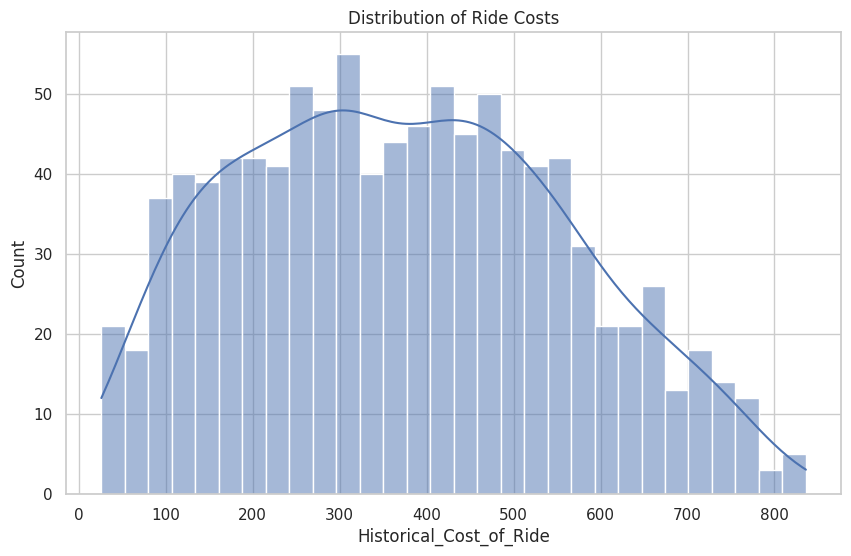

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Historical_Cost_of_Ride'], bins=30, kde=True)
plt.title('Distribution of Ride Costs')
plt.show()



The distribution of the Cost is almmost normal with only a few rides costing more that 600 units.

We will now start plotting all the features against the Ride Cost to understand which ones affect the dynamic pricing

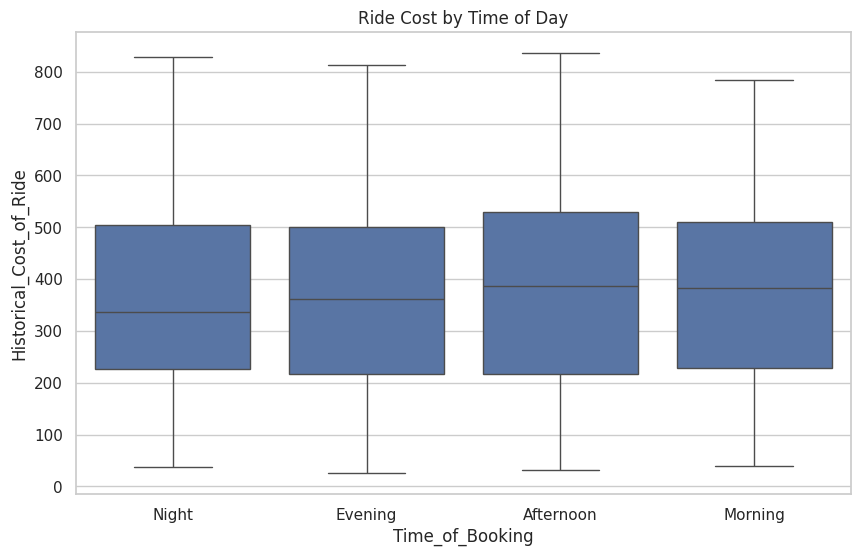

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Time_of_Booking', y='Historical_Cost_of_Ride', data=df)
plt.title('Ride Cost by Time of Day')
plt.show()



This boxplot shows that ride costs remain almost the same  across different times of day, with only a small  variation in median prices and spread. Afternoon rides have slightly higher median costs, showing a small peak in pricing during that period, while Night and Morning rides show slightly lower medians. Overall, the distribution is similar, indicating that time of booking has only a small impact on ride pricing in this dataset.

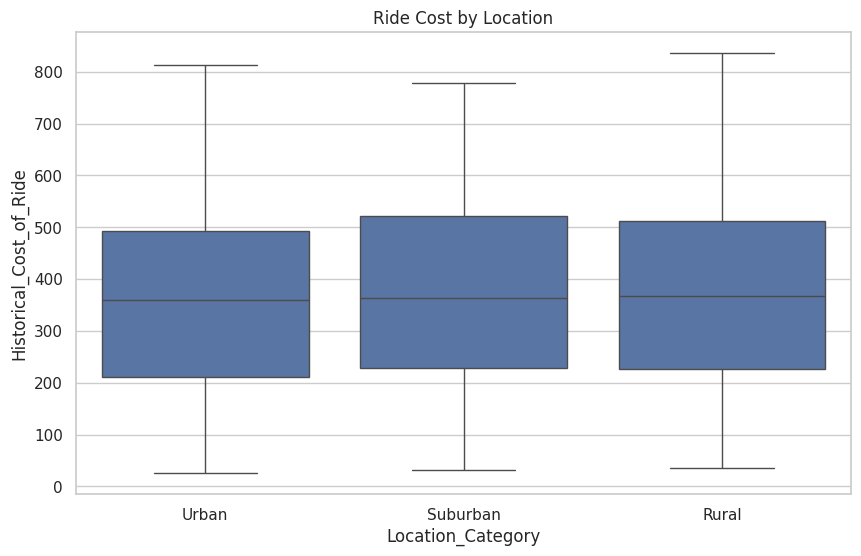

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Location_Category', y='Historical_Cost_of_Ride', data=df)
plt.title('Ride Cost by Location')
plt.show()



In this boxplot we compare the ride cost depending on the areas of the dataset (Urban, Suburban, Rural) The distributions are very similar except the that Suburban and Rural rides show slightly higher median prices compared to Urban. From this we could say that the location has very small impact on the ride pricing in this dataset.

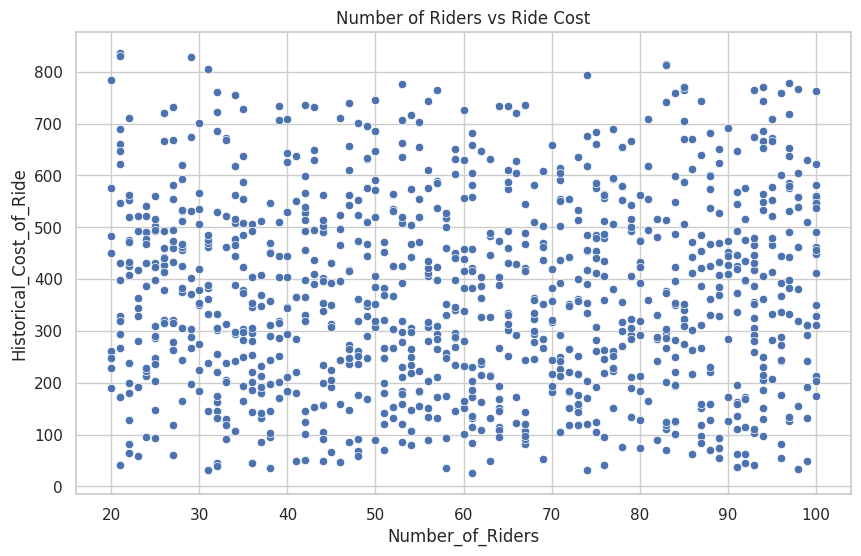

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number_of_Riders', y='Historical_Cost_of_Ride', data=df)
plt.title('Number of Riders vs Ride Cost')
plt.show()


In this plot each dot represends a ride

X-axis: number of riders  requesting rides at that moment

Y-axis: ride cost

We can say that ride prices range from very low to very high across all rider counts. There is a slight trend as the number of riders increases (especially around 70+), there's slightly more clustering in the higher cost range, but in general there is not any strong linear relationship.

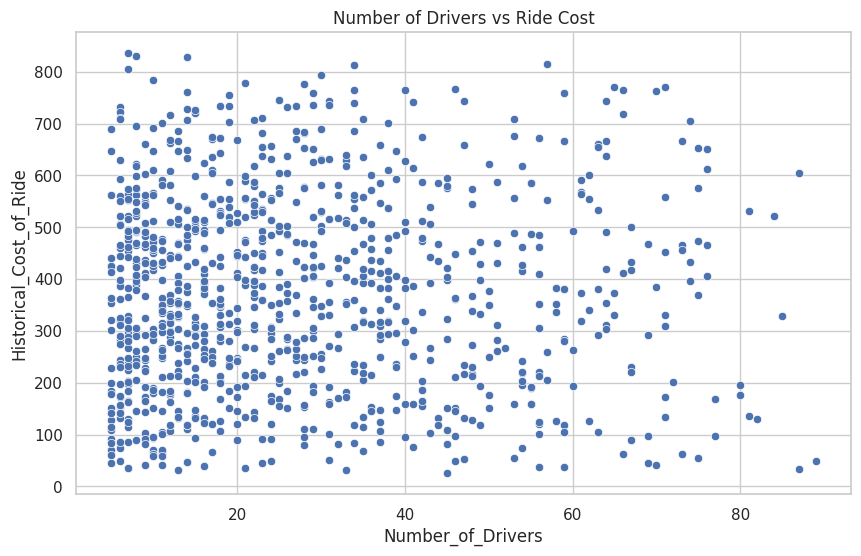

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number_of_Drivers', y='Historical_Cost_of_Ride', data=df)
plt.title('Number of Drivers vs Ride Cost')
plt.show()


In this plot each dot represends a ride

X-axis: number of drivers available at that moment

Y-axis: ride cost

We can see that even if costs vary  across all driver availability levels, there is a small trend showing that ride costs are still high even when many drivers are available. This mean that driver supply is not really a factor that affects the ride pricing.

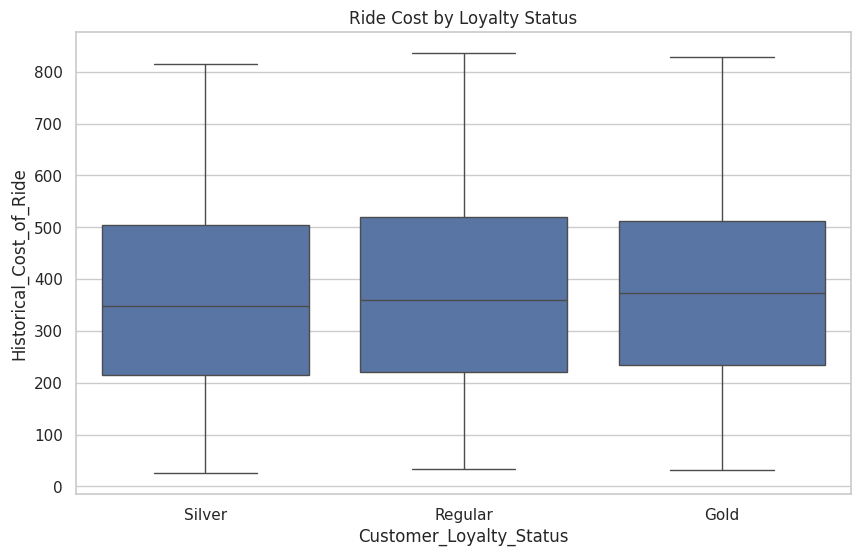

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Customer_Loyalty_Status', y='Historical_Cost_of_Ride', data=df)
plt.title('Ride Cost by Loyalty Status')
plt.show()

In this plot we are trying to check if the ride price depends on the loyalty status. We can see that the medians are similar, but Gold customers have a bit higher median ride cost.

This led us to the following questions:

1.   Are Gold loyal customers booking more expensive rides maybe with better cars or longer trips?

2.   Is the pricing algorithm unintentionally charging more the higher-tier users?
To answer these question we will now plot loyalty and vehicle type against ride cost.




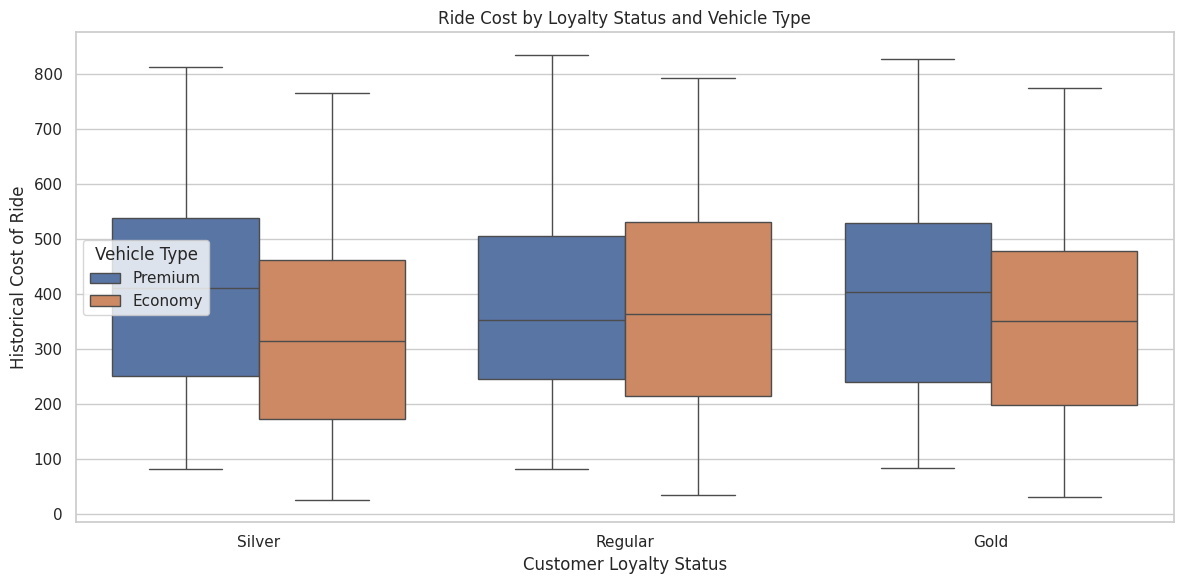

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Customer_Loyalty_Status', y='Historical_Cost_of_Ride', hue='Vehicle_Type')
plt.title('Ride Cost by Loyalty Status and Vehicle Type')
plt.xlabel('Customer Loyalty Status')
plt.ylabel('Historical Cost of Ride')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()


To answer the previous questions we plotted the vehicle type and the loyalty status agains the cost.

Higher loyalty status doesn’t seem to cause unfair price since loyal users (Golds) seem to use Premium vehicles more often which is normal to cost more. Therefore the algorithm seems to be pricing based on this behavior, so we can say that it is not bias.

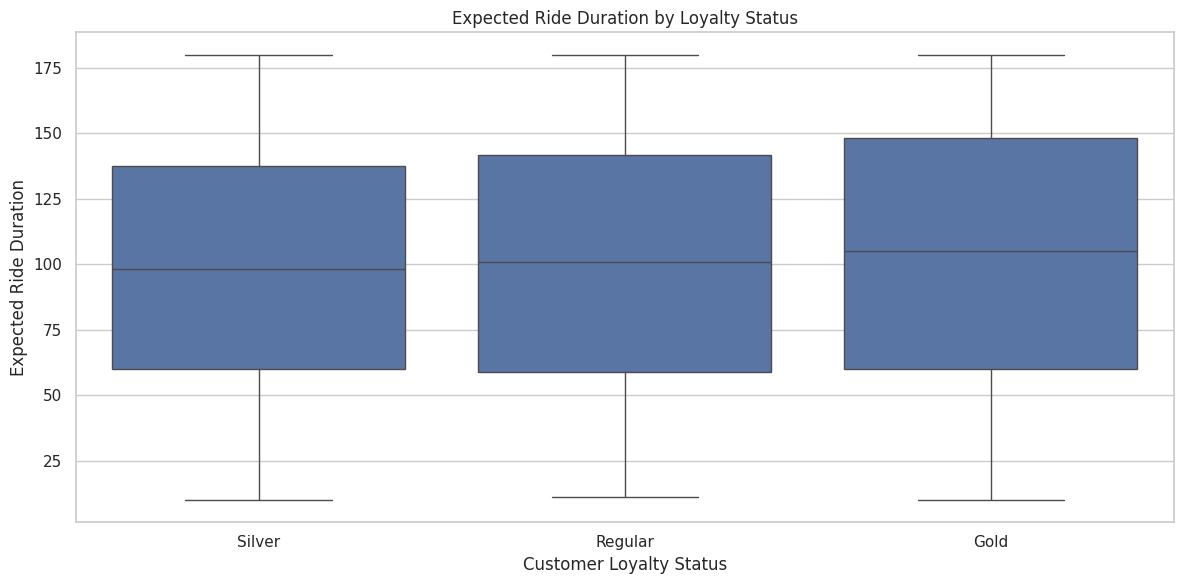

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Customer_Loyalty_Status', y='Expected_Ride_Duration')
plt.title('Expected Ride Duration by Loyalty Status')
plt.xlabel('Customer Loyalty Status')
plt.ylabel('Expected Ride Duration')
plt.tight_layout()
plt.show()

in this plot we can see that  Gold members seem to take a bit longer rides on average, as their median is a bit higher than the others. After seing this we  could say that more loyal customers may be using the service for longer trips, potentially due to benefits or trust developed over time. Overall, loyalty status does not dramatically affect ride duration. There still is a small upward trend when loyalty increases.

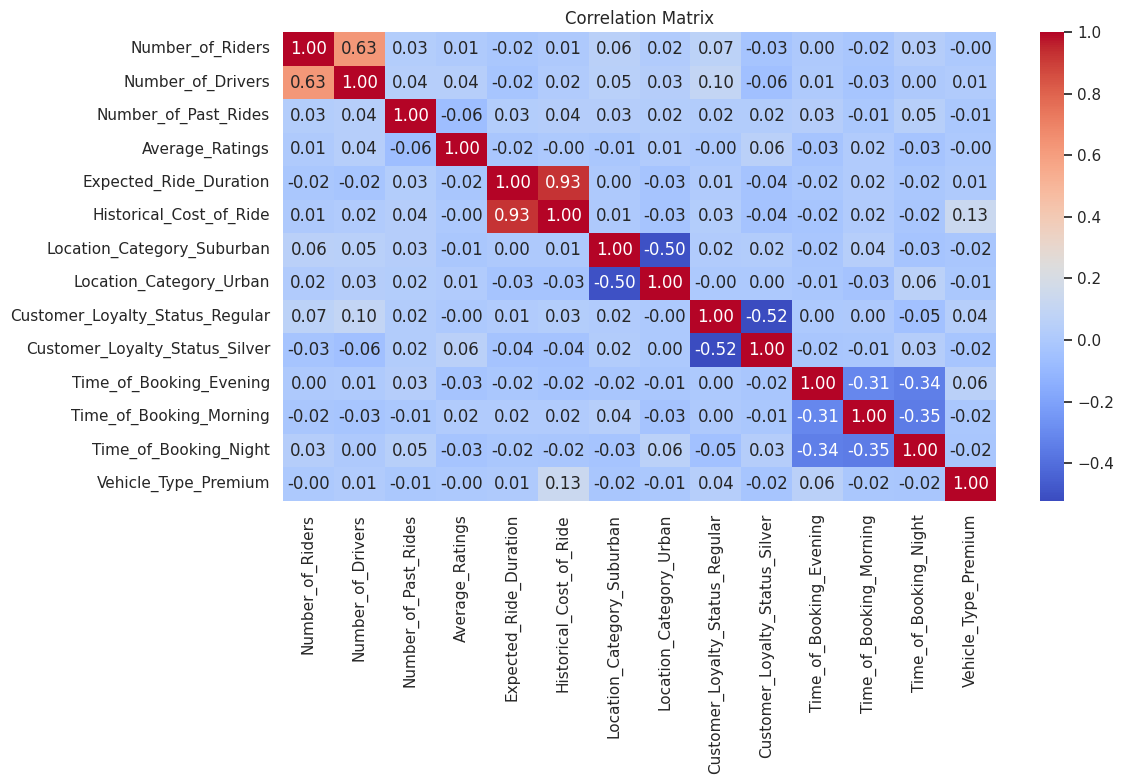

In [ ]:
# Convert categorical to numeric for correlation
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



Demand & Supply Correlation:
Amount of drivers and riders have a strong positive correlation (0.63) which tells us that these two values tend to rise together.

Historical Cost of Ride: Expected Duration is correlated with Historical_Cost_of_Ride (0.93), which makes sense  since longer rides cost more.

Historical_Cost_of_Ride has very weak correlations with all other variables, the highest one is 0.13 with Vehicle_Type_Premium indicating that the type of vehicle also affects pricing.


Time of Booking variables have low correlations with cost and with each other which tells us that they have almost no impact.

 **Conclutions:**
Ride duration is the dominant factor since price depends on how long each ride is. However, ride cost is also influenced by interactions and nonlinear relationships from other features such as Customer loyalty status , Supply and demand. Therefore we will use as a predicting model a tree-based model like Random Forest, which can handle complex patterns better than linear models.

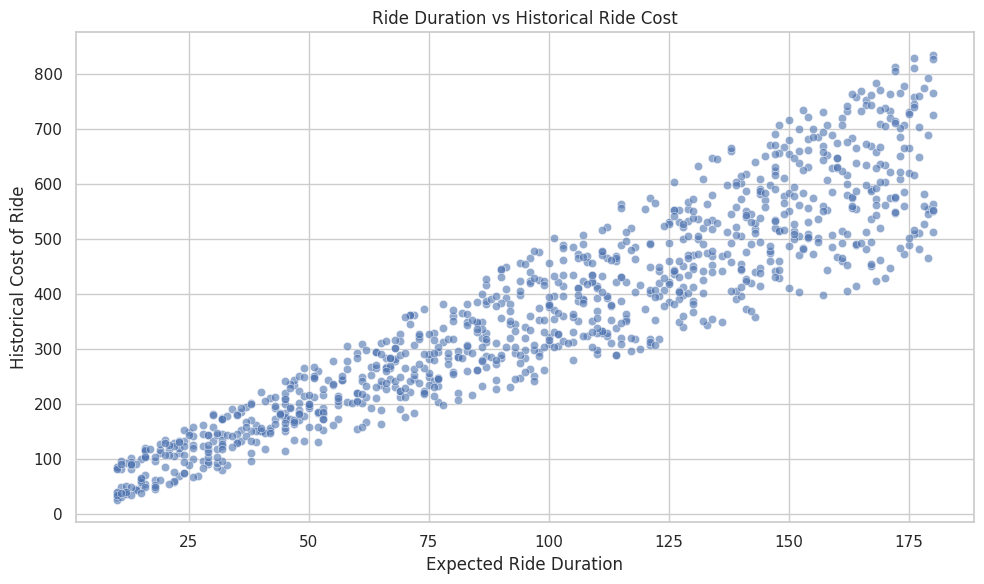

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Expected_Ride_Duration', y='Historical_Cost_of_Ride', alpha=0.6)

# Add labels and title
plt.title('Ride Duration vs Historical Ride Cost')
plt.xlabel('Expected Ride Duration')
plt.ylabel('Historical Cost of Ride')

# Show plot
plt.tight_layout()
plt.show()


After seing that the correlation matrix is showing that the Duration is the dominant factor of dynamic pricing, we plotted Ride Duration against Cost and that is verifying it since they are linearly related.

Now we are going to plot a few more things just to have a clearer view of our data

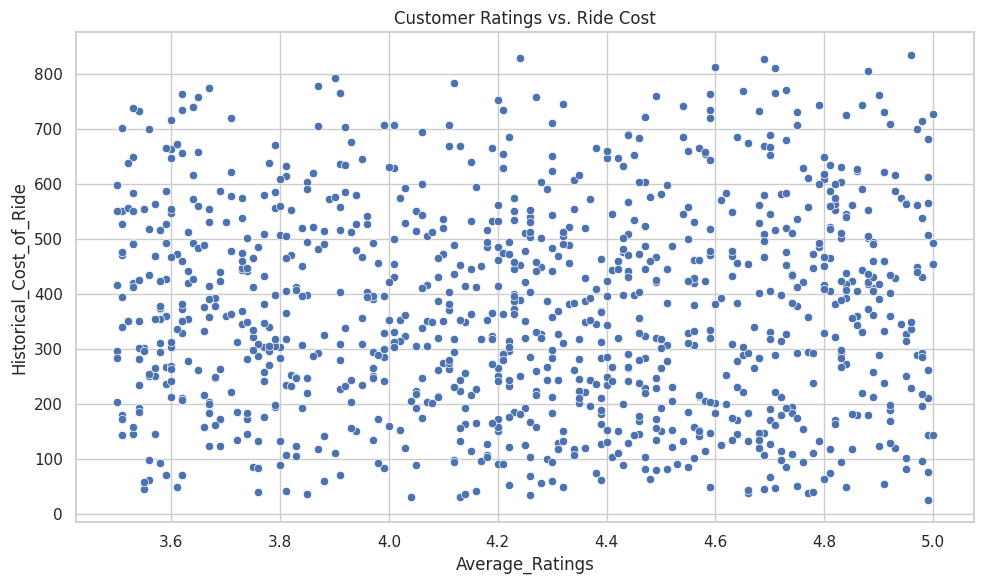

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Average_Ratings', y='Historical_Cost_of_Ride', data=df)
plt.title('Customer Ratings vs. Ride Cost')
plt.tight_layout()
plt.show()


Here again each dot is represending a ride.
This scatter plot shows the relationship between Customer Ratings (x-axis) and Ride Cost (y-axis).

We cannot really see any upward or downward trend. Ride costs stay highly variable regardless of how high or low the average rating is.

This tells us  that customer rating has little to no impact on the price and maybe they should especially for loyalty members.

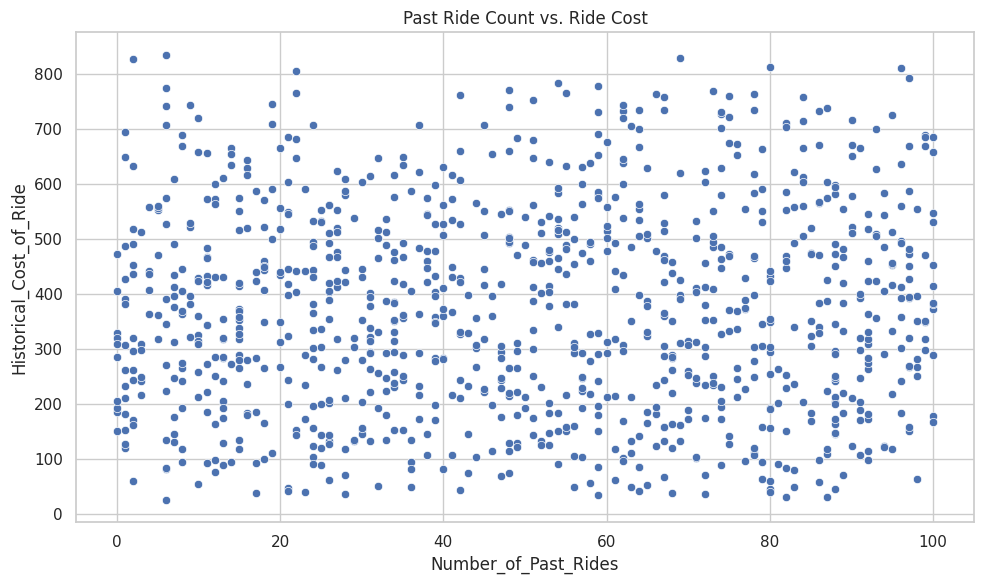

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number_of_Past_Rides', y='Historical_Cost_of_Ride', data=df)
plt.title('Past Ride Count vs. Ride Cost')
plt.tight_layout()
plt.show()


This scatter plot does not show a relationship between the number of past rides and the historical cost of rides. Ride costs appear widely scattered across all levels of past ride count. This indicates that customer history does not really impact pricing.

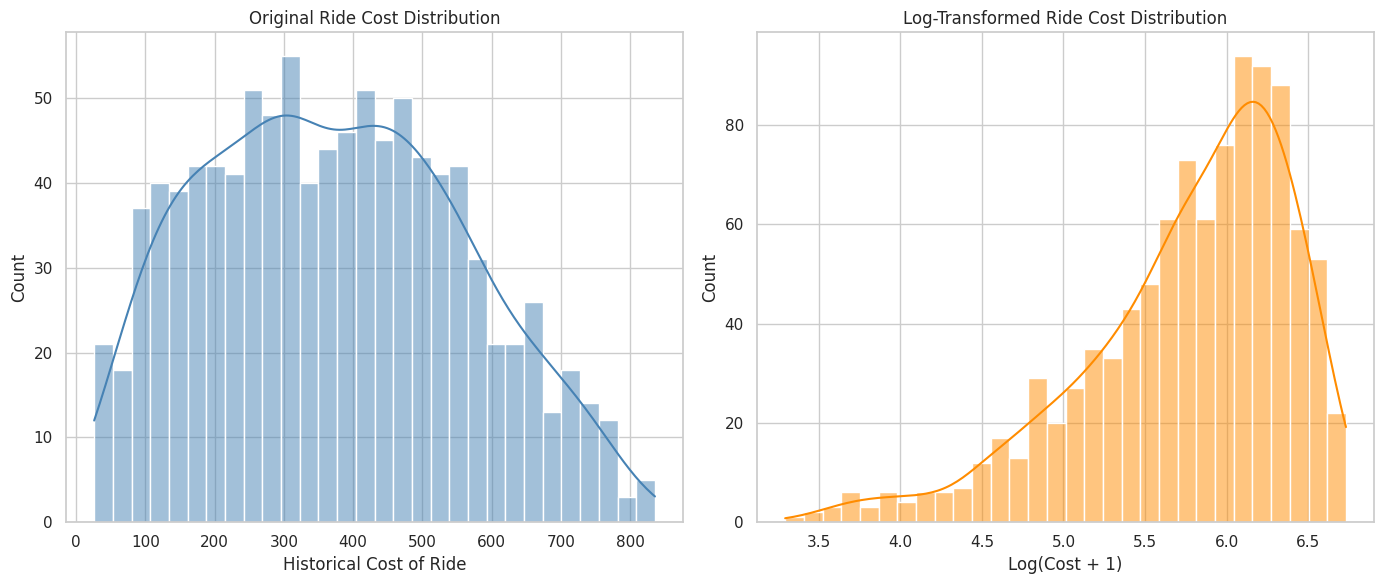

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log transformation to the target variable
df['Log_Cost'] = np.log1p(df['Historical_Cost_of_Ride'])

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot original ride cost distribution
sns.histplot(df['Historical_Cost_of_Ride'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original Ride Cost Distribution')
axes[0].set_xlabel('Historical Cost of Ride')
axes[0].set_ylabel('Count')

# Plot log-transformed cost distribution
sns.histplot(df['Log_Cost'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Log-Transformed Ride Cost Distribution')
axes[1].set_xlabel('Log(Cost + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


Original ride cost is right-skewed and most rides cost between 100–500 units.
A smaller number of rides are 700 or more.
This can affect the performance of some models because outliers pull the average up. So in order to avoid biasing the models we compress high values and even out the distribution, making it more symmetric and normal-like.

This transformation makes the data easier for models to learn and less sensitive to large price outliers.


# Model Fitting

The first model that we will use for predictions is going to be Random Forest.

R² Score: 0.8520
RMSE: 73.46


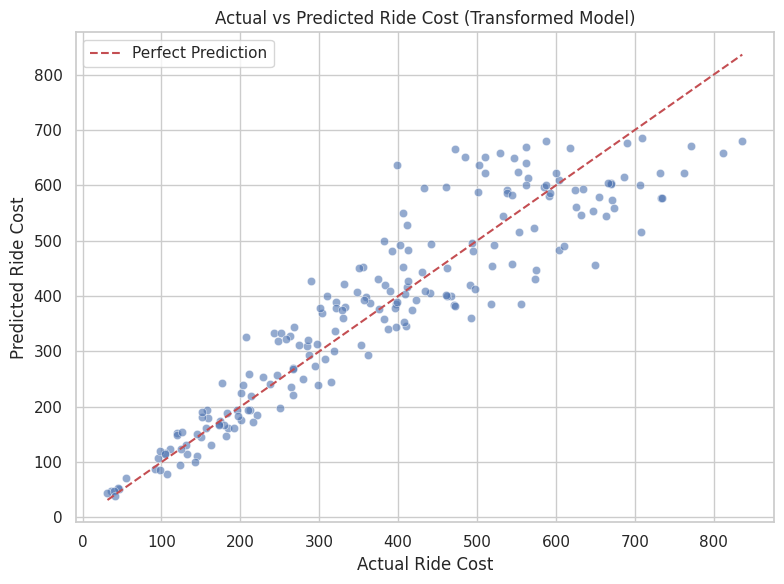

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Drop target column only
features = df_encoded.drop(columns=['Historical_Cost_of_Ride'])
target = df['Log_Cost']

# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict in log scale
log_preds = model.predict(X_test)

# Convert back to original scale
actual = np.expm1(y_test)
predicted = np.expm1(log_preds)

# Evaluate
r2 = r2_score(actual, predicted)
rmse = mean_squared_error(actual, predicted) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# Plot actual vs predicted
results = pd.DataFrame({'Actual': actual, 'Predicted': predicted})
plt.figure(figsize=(8,6))
sns.scatterplot(data=results, x='Actual', y='Predicted', alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', label='Perfect Prediction')
plt.title("Actual vs Predicted Ride Cost (Transformed Model)")
plt.xlabel("Actual Ride Cost")
plt.ylabel("Predicted Ride Cost")
plt.legend()
plt.tight_layout()
plt.show()


This plot shows how well the Random Forest model predicted ride costs after applying a log transformation.

Most points are pretty close to the red dashed line which represents perfect predictions. This means  that the model generally predicts well.

However, there’s still some spread especially for higher ride costs showing the model is less accurate for expensive rides.

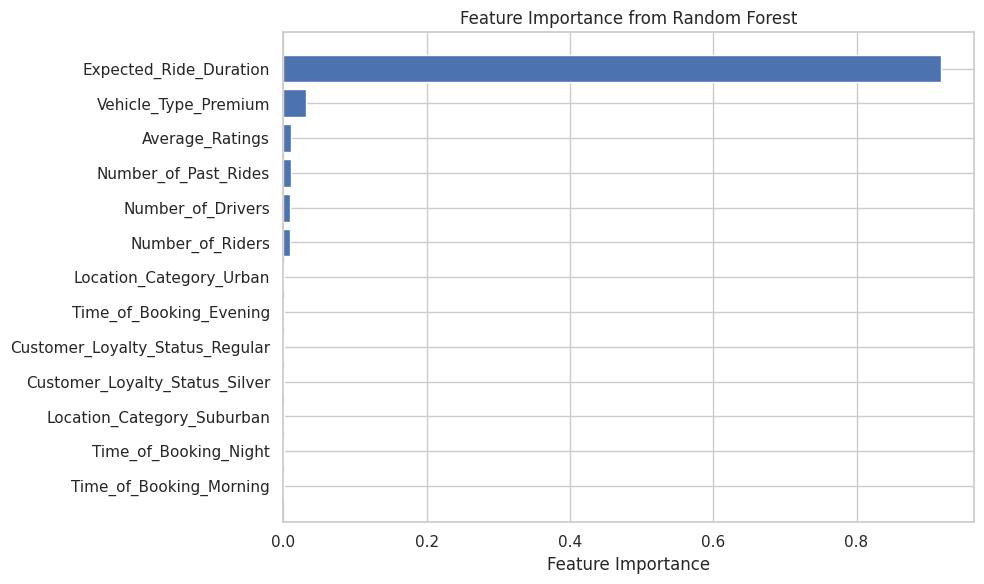

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Here we can see again the the dominanting feature is the Ride duration so we thought to remove it form the dataset and try to train the model again without it to see how that can affect the predictions.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df['Log_Cost'] = np.log1p(df['Historical_Cost_of_Ride'])
df['Rider_Driver_Ratio'] = df['Number_of_Riders'] / (df['Number_of_Drivers'] + 1)
df['Peak_Hour'] = df['Time_of_Booking'].apply(lambda x: 1 if x in ['Evening', 'Morning'] else 0)

# One-hot encoding for categorical features
df_encoded = pd.get_dummies(df, columns=[
    'Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type'
], drop_first=True)

# Function to train and evaluate model
def train_and_evaluate(features, target, label):
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)
    actual = np.expm1(y_test)
    predicted = np.expm1(preds_log)
    r2 = r2_score(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    print(f"{label} → R² Score: {r2:.4f}, RMSE: {rmse:.2f}")
    return label, r2, rmse

# Model A: With Expected_Ride_Duration
features_A = df_encoded.drop(columns=['Historical_Cost_of_Ride', 'Log_Cost'])
target = df['Log_Cost']
result_A = train_and_evaluate(features_A, target, 'Model with Duration')

# Model B: Without Expected_Ride_Duration
features_B = df_encoded.drop(columns=['Historical_Cost_of_Ride', 'Log_Cost', 'Expected_Ride_Duration'])
result_B = train_and_evaluate(features_B, target, 'Model without Duration')

# Display comparison
results_df = pd.DataFrame([result_A, result_B], columns=['Model', 'R2_Score', 'RMSE'])
print("\nModel Comparison:")
print(results_df)


Model with Duration → R² Score: 0.8480, RMSE: 74.44
Model without Duration → R² Score: -0.1539, RMSE: 205.11

Model Comparison:
                    Model  R2_Score        RMSE
0     Model with Duration  0.848019   74.440307
1  Model without Duration -0.153862  205.111538


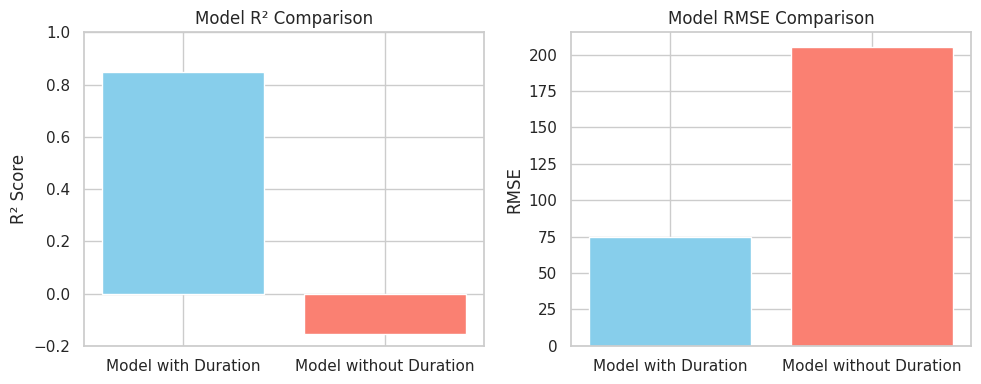

In [ ]:
import matplotlib.pyplot as plt

# Plot R² comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(results_df['Model'], results_df['R2_Score'], color=['skyblue', 'salmon'])
plt.ylim(-0.2, 1)
plt.ylabel('R² Score')
plt.title('Model R² Comparison')

# Plot RMSE comparison
plt.subplot(1, 2, 2)
plt.bar(results_df['Model'], results_df['RMSE'], color=['skyblue', 'salmon'])
plt.ylabel('RMSE')
plt.title('Model RMSE Comparison')

plt.tight_layout()
plt.show()


 The model including ride duration achieved a  R² score of 0.85 and a low RMSE of 74.44 showing high accuracy.


In contrast, the model excluding this feature performed very poorly (R² = -0.15, RMSE = 205.11). This is telling us that  other factors like supply, demand, or loyalty alone are not enough to predict prices accurately.


This confirms that ride duration is currently the dominant factor in pricing decisions for this dataset.  

Dynamic pricing strategies need to incorporate additional real-time features to reduce this dependency.

Finally we will test a few other models in case they have higher predicting scores. We will use XGBoost and Linear Regression.

In [ ]:
!pip install xgboost


In [ ]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = np.expm1(lr_model.predict(X_test))
lr_r2 = r2_score(actual, lr_preds)
lr_rmse = mean_squared_error(actual, predicted) ** 0.5



# --- XGBoost Regressor ---
xgb_model = XGBRegressor(random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_preds = np.expm1(xgb_model.predict(X_test))
xgb_r2 = r2_score(actual, xgb_preds)
xgb_rmse = mean_squared_error(actual, xgb_preds) ** 0.5

# --- Results ---
print("\nModel Comparison:")
print(f"Random Forest   → R²: {r2:.4f} | RMSE: {rmse:.2f}")
print(f"Linear Regression → R²: {lr_r2:.4f} | RMSE: {lr_rmse:.2f}")
print(f"XGBoost          → R²: {xgb_r2:.4f} | RMSE: {xgb_rmse:.2f}")



Model Comparison:
Random Forest   → R²: 0.8520 | RMSE: 73.46
Linear Regression → R²: 0.7478 | RMSE: 73.46
XGBoost          → R²: 0.8403 | RMSE: 76.32


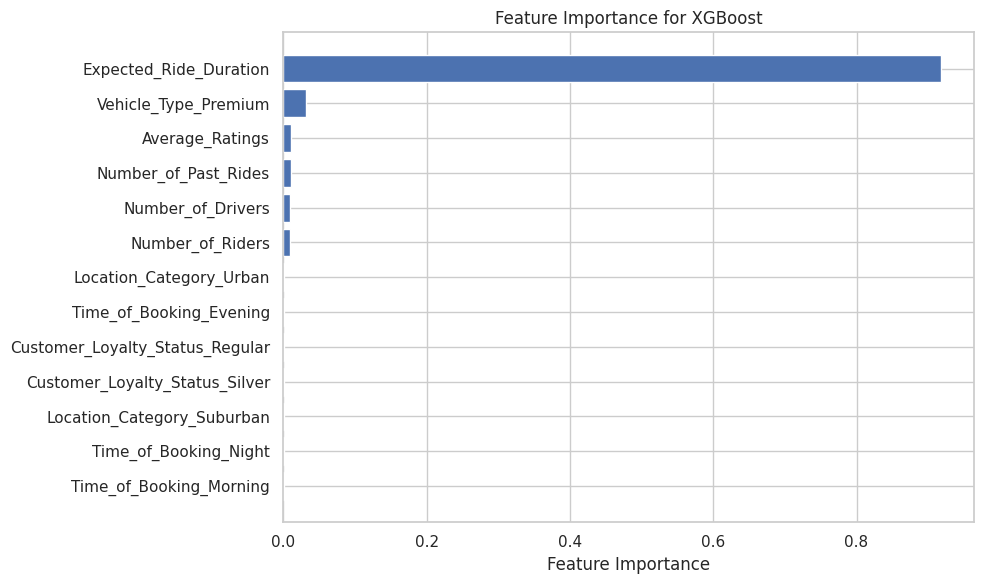

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Based on the results, compraring these models with Random Forest, Random Forest has the best results so we will not do the same analysis for the others models


# Fairness and Economic Implications

* Loyal or premium users might pay more, even though they should be rewarded, they sometimes get higher prices which is unfair.


* Cases with fewer drivers and prices are still high. This is a problem for  people in places with low driver availability like rural areas.

* Should traffic affect pricing, is that fair?


* Users don’t know how prices are set an this  makes it hard to trust the system.

* Rising prices affect people differently because rich people can still pay, but lower-income users might have to find alternative ways to travel.

* The model may focus only on profits, not on fairness or helping people who really need rides.


* Is it fair across locations? People in cities may get better service and pricing than those in suburbs or rural places. Is it more fair if prices are lower in rural areas? .

* Loyal or premium users might be paying more, even though they should be rewarded with benefits, this feels unfair and may affect their trust.


Data Source
https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset/data